<a href="https://colab.research.google.com/github/luquetabertolini/Checkpoint_2-SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [7]:
# 1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique X (três entradas) e y (fonte).
import pandas as pd

df = pd.read_csv('aneel_classificacao_orange.csv')


In [8]:
# Tipos das colunas
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB
None


In [9]:
# Contagem por Classes
print(df['fonte'].value_counts())

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


In [10]:
# Valores Ausentes
print(df.isnull().sum())

potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


In [11]:
# Distribuições (Estatísticas Descritivas para colunas numéricas)
print(df.describe())

        potencia_kw     latitude    longitude
count  3.876000e+03  3876.000000  3876.000000
mean   4.201468e+04   -12.693951   -46.158299
std    3.016366e+05     9.500523     8.357453
min    1.600000e-01   -33.722806   -69.941389
25%    4.400000e+02   -21.142110   -52.561817
50%    1.268000e+04   -10.469532   -47.393697
75%    3.000000e+04    -4.127788   -41.280013
max    1.123310e+07     3.831392     0.000000


In [12]:
# Explicação de X e y
print("As variáveis de entrada (X) são: 'potencia_kw', 'latitude', e 'longitude'.")
print("A variável alvo (y) é: 'fonte'.")

As variáveis de entrada (X) são: 'potencia_kw', 'latitude', e 'longitude'.
A variável alvo (y) é: 'fonte'.


In [13]:
# 2. Faça uma divisão estratificada de treino/teste, por exemplo 80%/20%, com semente fixa.
# Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino.
from sklearn.model_selection import train_test_split

# Definir as variáveis de entrada (X) e a variável alvo (y)
X = df[['potencia_kw', 'latitude', 'longitude']]
y = df['fonte']

# Realizar a divisão estratificada treino/teste (80%/20%) com semente fixa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

print("\nDistribuição de classes em y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição de classes em y_test:")
print(y_test.value_counts(normalize=True))

Shape de X_train: (3100, 3)
Shape de X_test: (776, 3)
Shape de y_train: (3100,)
Shape de y_test: (776,)

Distribuição de classes em y_train:
fonte
Hidráulica    0.380645
Solar         0.309677
Eólica        0.309677
Name: proportion, dtype: float64

Distribuição de classes em y_test:
fonte
Hidráulica    0.381443
Solar         0.309278
Eólica        0.309278
Name: proportion, dtype: float64


In [14]:
# 3. Escolha, justifique e treine três classificadores diferentes usando a mesma divisão.
# Eles não estão importados nem implementados neste notebook.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Escalar as features
# Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Treinamento dos Classificadores\n")

# 1. Regressão Logística
# Justificativa: Modelo linear baseline, bom para interpretar a influência de cada feature.
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
print("Regressão Logística treinada.")

# 2. Random Forest Classifier
# Justificativa: Modelo de ensemble robusto, lida bem com não-linearidades e menos sensível a outliers.
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train_scaled, y_train)
print("Random Forest Classifier treinado.")

# 3. K-Nearest Neighbors (KNN)
# Justificativa: Classificador não-paramétrico baseado em proximidade, simples e intuitivo.
model_knn = KNeighborsClassifier(n_neighbors=5) # 5 vizinhos como um ponto de partida comum
model_knn.fit(X_train_scaled, y_train)
print("K-Nearest Neighbors treinado.")

print("\nModelos treinados com sucesso. Agora podemos compará-los.")

 Treinamento dos Classificadores

Regressão Logística treinada.
Random Forest Classifier treinado.
K-Nearest Neighbors treinado.

Modelos treinados com sucesso. Agora podemos compará-los.



--- Avaliação dos Modelos de Classificação ---

### Logistic Regression

Accuracy: 0.8247
Classification Report (macro avg):
  Precision: 0.8282
  Recall: 0.8214
  F1-Score: 0.8197
Confusion Matrix:
[[216  16   8]
 [ 20 257  19]
 [ 51  22 167]]


### Random Forest Classifier

Accuracy: 0.9755
Classification Report (macro avg):
  Precision: 0.9769
  Recall: 0.9741
  F1-Score: 0.9753
Confusion Matrix:
[[235   4   1]
 [  2 294   0]
 [  5   7 228]]


### K-Nearest Neighbors

Accuracy: 0.9652
Classification Report (macro avg):
  Precision: 0.9663
  Recall: 0.9636
  F1-Score: 0.9648
Confusion Matrix:
[[231   6   3]
 [  1 292   3]
 [  6   8 226]]


--- Tabela Comparativa de Algoritmos ---
                          Accuracy  Precision (macro avg)  Recall (macro avg)  \
Model                                                                           
Logistic Regression         0.8247                 0.8282              0.8214   
Random Forest Classifier    0.9755                 0.9769        

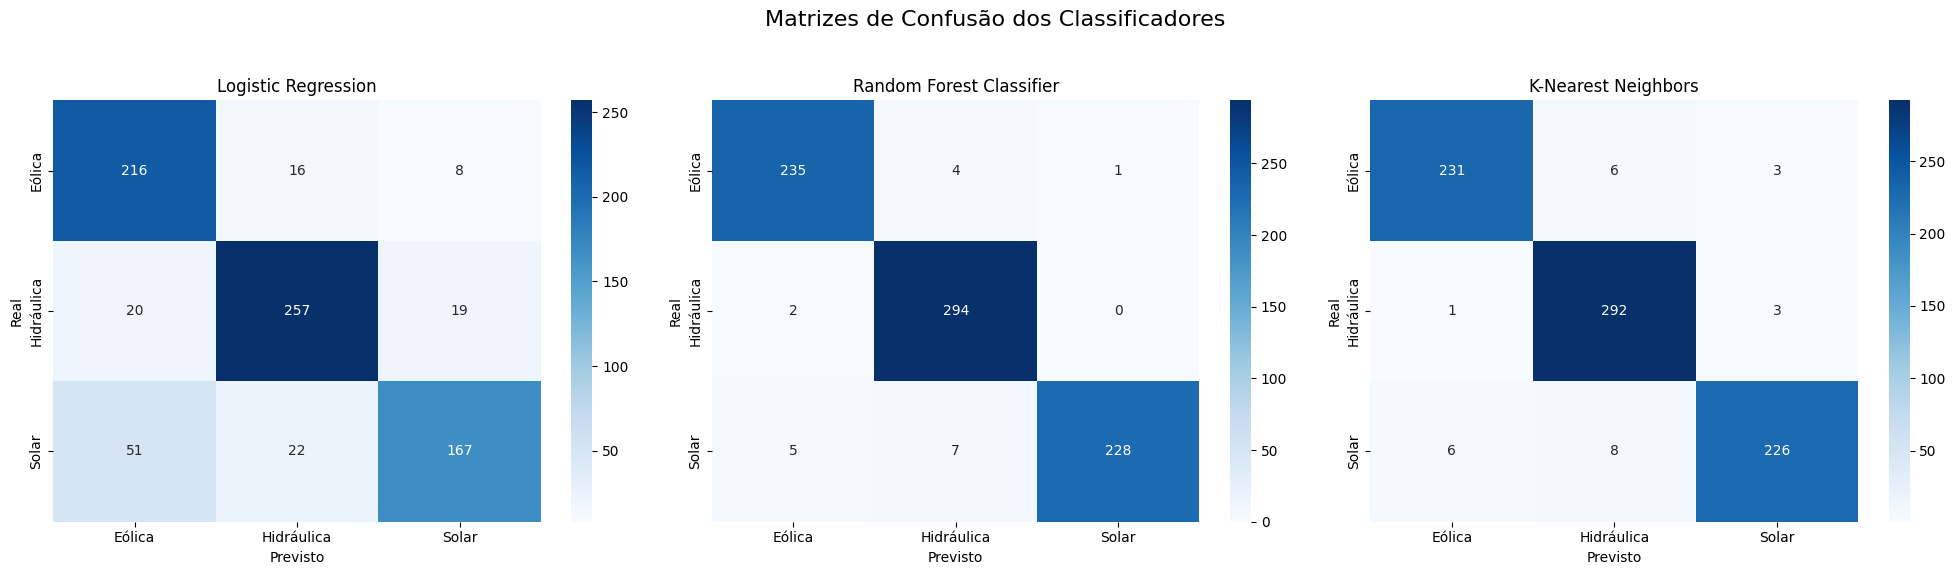

In [21]:
# 4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário para armazenar os resultados dos modelos
results = {}

# Lista de modelos e seus nomes (assumindo que model_lr, model_rf, model_knn já foram treinados)
models = {
    "Logistic Regression": model_lr,
    "Random Forest Classifier": model_rf,
    "K-Nearest Neighbors": model_knn
}

print("\n--- Avaliação dos Modelos de Classificação ---\n")

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    # Usamos average='macro' para considerar todas as classes igualmente,
    # o que é bom para classes desbalanceadas ou para uma visão geral do desempenho.
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision (macro avg)": report['macro avg']['precision'],
        "Recall (macro avg)": report['macro avg']['recall'],
        "F1-Score (macro avg)": report['macro avg']['f1-score'],
        "Confusion Matrix": conf_matrix,
        "Classification Report": report
    }

    print(f"### {name}\n")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report (macro avg):")
    print(f"  Precision: {report['macro avg']['precision']:.4f}")
    print(f"  Recall: {report['macro avg']['recall']:.4f}")
    print(f"  F1-Score: {report['macro avg']['f1-score']:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("\n")

# Tabela Comparativa
comparison_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [res["Accuracy"] for res in results.values()],
    "Precision (macro avg)": [res["Precision (macro avg)"] for res in results.values()],
    "Recall (macro avg)": [res["Recall (macro avg)"] for res in results.values()],
    "F1-Score (macro avg)": [res["F1-Score (macro avg)"] for res in results.values()]
})

print("--- Tabela Comparativa de Algoritmos ---")
print(comparison_df.set_index("Model").round(4))

# Visualização das Matrizes de Confusão
print("\n--- Visualização das Matrizes de Confusão ---")
class_names = y_train.unique() # Obter os nomes das classes
class_names.sort()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Matrizes de Confusão dos Classificadores', fontsize=16)

for i, (name, res) in enumerate(results.items()):
    sns.heatmap(
        res["Confusion Matrix"],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i]
    )
    axes[i].set_title(name)
    axes[i].set_xlabel('Previsto')
    axes[i].set_ylabel('Real')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use SigTipoGeracao, nomes, CEG ou descrições da fonte como entradas.

A avaliação dos modelos foi concluída com sucesso! Obtivemos as métricas de desempenho e as matrizes de confusão para cada um.

### Sumário dos Modelos:

**1. Regressão Logística:**
- Accuracy: 0.8247
- Precision (macro avg): 0.8282
- Recall (macro avg): 0.8214
- F1-Score (macro avg): 0.8197

**2. Random Forest Classifier:**
- Accuracy: 0.9755
- Precision (macro avg): 0.9769
- Recall (macro avg): 0.9741
- F1-Score (macro avg): 0.9753

**3. K-Nearest Neighbors (KNN):**
- Accuracy: 0.9652
- Precision (macro avg): 0.9663
- Recall (macro avg): 0.9636
- F1-Score (macro avg): 0.9648

### Qual Modelo Escolheria e Por Quê?

Considerando as métricas de desempenho, eu **escolheria o Random Forest Classifier**.

- O **Random Forest** apresentou as melhores métricas em todas as categorias (Accuracy, Precision, Recall, F1-Score), com valores acima de 0.97. Isso indica que ele é o modelo mais robusto e eficaz para esta tarefa de classificação, oferecendo um bom equilíbrio entre identificar corretamente as classes e ter poucos falsos positivos/negativos.
- O **K-Nearest Neighbors** também teve um desempenho muito bom, próximo ao Random Forest (acima de 0.96), o que é esperado para classificadores não-paramétricos que são sensíveis à estrutura de proximidade dos dados escalados.
- A **Regressão Logística**, sendo um modelo linear mais simples, teve um desempenho significativamente inferior (cerca de 0.82), servindo como uma boa linha de base, mas mostrando que a relação entre as características e a classe pode não ser estritamente linear.

### Quais Classes o Modelo Mais Confunde?

Analisando as matrizes de confusão (especialmente a do Random Forest, que é o melhor modelo):

O **Random Forest** confunde muito pouco as classes. Os maiores erros (números fora da diagonal principal) são:
- **Eólica confundida com Hidráulica**: 4 casos
- **Solar confundida com Hidráulica**: 7 casos
- **Hidráulica confundida com Solar**: 0 casos (o modelo não previu 'Solar' incorretamente quando era 'Hidráulica')

No geral, a classe **Hidráulica** parece ser a mais frequentemente confundida por outros tipos (Eólica e Solar sendo classificadas como Hidráulica), embora em um número muito pequeno de ocorrências para o Random Forest. A Regressão Logística mostrava um pouco mais de confusão da classe Solar com Hidráulica (22 casos) e Eólica com Hidráulica (16 casos).

### Por que Potência/Localização Podem Não Bastar para uma Aplicação Real?

Embora os modelos, especialmente o Random Forest, tenham atingido alta performance com `potencia_kw`, `latitude` e `longitude`, essas features podem não ser suficientes para uma aplicação real por várias razões:

1.  **Variações Regionais/Temporais**: A localização geográfica é um bom indicador, mas as condições climáticas, geológicas e regulatórias que definem a viabilidade de uma fonte de energia podem variar significativamente dentro de uma mesma região ou ao longo do tempo. Latitude e longitude são apenas proxies.
2.  **Tecnologia e Inovação**: A potência e localização não capturam o avanço tecnológico. Novas tecnologias podem permitir a instalação de certos tipos de usinas em locais antes inviáveis ou com diferentes perfis de potência.
3.  **Fatores Econômicos e Regulatórios**: Decisões sobre o tipo de fonte de energia para um empreendimento são fortemente influenciadas por incentivos fiscais, custos de instalação e operação, políticas energéticas governamentais e demanda local, que não estão representados nessas três variáveis.
4.  **Características Específicas do Local**: Detalhes como topografia, proximidade de recursos hídricos (para hidrelétricas), disponibilidade de vento consistente (para eólicas), ou insolação média ao longo do ano (para solar) são mais específicos do que apenas latitude/longitude e são cruciais.
5.  **Dados Históricos vs. Futuro**: Os modelos são treinados com dados históricos. Mudanças na legislação, preços de energia ou matérias-primas podem alterar o padrão de implantação de novas usinas, tornando o modelo menos preciso para empreendimentos futuros.
6.  **Desbalanceamento de Classes (potencial)**: Embora nossa amostra esteja relativamente balanceada, em uma aplicação real, algumas fontes podem ser muito mais raras, dificultando a classificação precisa sem técnicas de tratamento de desbalanceamento ou mais dados.

Em resumo, para uma aplicação real robusta, seria ideal incorporar mais dados contextuais e descritivos sobre o empreendimento e o ambiente em que ele está inserido, além da potência e localização básicas.


# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [15]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [16]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [17]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [18]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

Primeiras linhas:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0



Valores ausentes por coluna:


,0
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0



Resumo estatístico:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


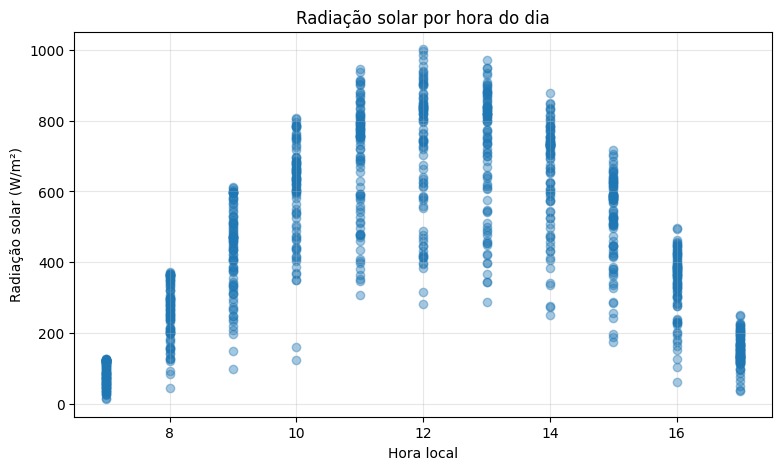

Entradas X:
['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']

Saída y:
radiacao_w_m2


In [23]:
# 1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina X (cinco entradas) e y (radiacao_w_m2).

df = pd.read_csv("meteo_regressao_orange.csv")

df["data_hora"] = pd.to_datetime(df["data_hora"])

df = df.sort_values("data_hora").reset_index(drop=True)

print("Primeiras linhas:")
display(df.head())

print("\nValores ausentes por coluna:")
display(df.isnull().sum())

print("\nResumo estatístico:")
display(df.describe())

# Visualização inicial
plt.figure(figsize=(9, 5))

plt.scatter(
    df["hora"],
    df["radiacao_w_m2"],
    alpha=0.4
)

plt.xlabel("Hora local")
plt.ylabel("Radiação solar (W/m²)")
plt.title("Radiação solar por hora do dia")
plt.grid(alpha=0.3)
plt.show()

# X = cinco entradas
colunas_x = [
    "temperatura_c",
    "umidade_pct",
    "nuvens_pct",
    "vento_kmh",
    "hora"
]

X = df[colunas_x]

# y = variável alvo
y = df["radiacao_w_m2"]

print("Entradas X:")
print(colunas_x)

print("\nSaída y:")
print("radiacao_w_m2")

### Explicação das colunas

- **data_hora:** data e hora local do registro.
- **temperatura_c:** temperatura do ar em °C.
- **umidade_pct:** umidade relativa do ar em %.
- **nuvens_pct:** cobertura de nuvens em %.
- **vento_kmh:** velocidade do vento em km/h.
- **hora:** hora local do registro, entre 7h e 17h.
- **radiacao_w_m2:** radiação solar horizontal média em W/m², usada como variável alvo.

A coluna `radiacao_w_m2` é usada somente como **y**, e não aparece entre as entradas de `X`.


In [24]:
# 2. Mantenha as linhas em ordem de data_hora: use aproximadamente 80% das primeiras horas para treino e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.

corte = int(len(df) * 0.80)

X_treino = X.iloc[:corte].copy()
X_teste = X.iloc[corte:].copy()

y_treino = y.iloc[:corte].copy()
y_teste = y.iloc[corte:].copy()

print("Total de registros:", len(df))
print("Treino:", len(X_treino))
print("Teste:", len(X_teste))

print("\nPeríodo de treino:")
print(df["data_hora"].iloc[0], "até", df["data_hora"].iloc[corte - 1])

print("\nPeríodo de teste:")
print(df["data_hora"].iloc[corte], "até", df["data_hora"].iloc[-1])



Total de registros: 1001
Treino: 800
Teste: 201

Período de treino:
2025-04-01 07:00:00 até 2025-06-12 14:00:00

Período de teste:
2025-06-12 15:00:00 até 2025-06-30 17:00:00


In [26]:
# 3. Escolha, justifique e treine três algoritmos de regressão diferentes com a mesma divisão. Os imports e a implementação são sua responsabilidade.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

modelo_linear = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", LinearRegression())
])

modelo_random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

modelo_gradient_boosting = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

modelos = {
    "Regressão Linear": modelo_linear,
    "Random Forest": modelo_random_forest,
    "Gradient Boosting": modelo_gradient_boosting
}

# Treinamento
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    print(nome, "treinado.")

Regressão Linear treinado.
Random Forest treinado.
Gradient Boosting treinado.


# 3.
# Modelos escolhidos:

1. **Regressão Linear:** modelo simples de referência.
2. **Random Forest Regressor:** consegue representar relações não lineares.
3. **Gradient Boosting Regressor:** cria árvores sequencialmente para corrigir erros anteriores.


--- Avaliação dos Modelos de Regressão ---

### Regressão Linear

MAE: 145.20 W/m²
MSE: 30034.20 (W/m²)²
R²: 0.3598


### Random Forest

MAE: 66.40 W/m²
MSE: 7210.08 (W/m²)²
R²: 0.8463


### Gradient Boosting

MAE: 67.77 W/m²
MSE: 7419.76 (W/m²)²
R²: 0.8419


--- Tabela Comparativa de Algoritmos de Regressão ---
                        MAE         MSE      R²
Modelo                                         
Regressão Linear   145.2049  30034.2011  0.3598
Random Forest       66.3994   7210.0838  0.8463
Gradient Boosting   67.7678   7419.7593  0.8419


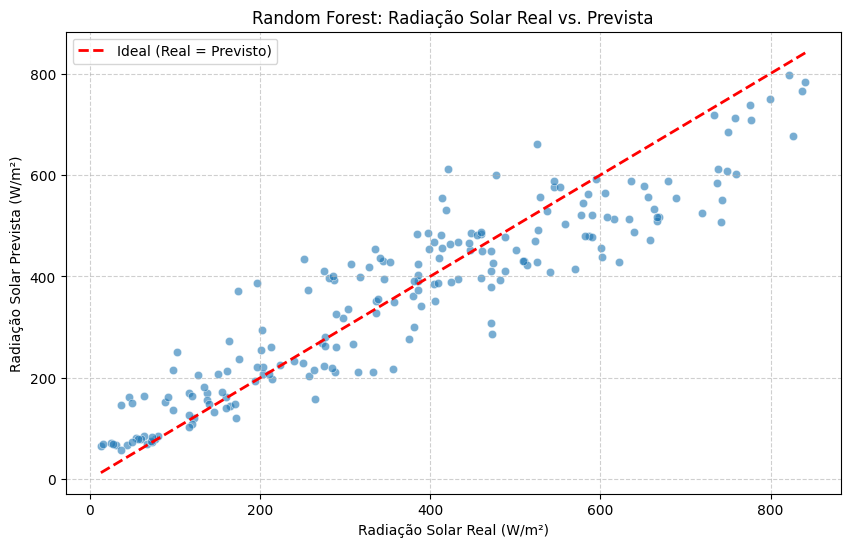

In [27]:
# Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário para armazenar os resultados dos modelos de regressão
regression_results = {}

# Modelos treinados estão no dicionário 'modelos' do código anterior
# 'modelos' contém: modelo_linear, modelo_random_forest, modelo_gradient_boosting

print("--- Avaliação dos Modelos de Regressão ---\n")

for name, model in modelos.items():
    y_pred = model.predict(X_teste)

    mae = mean_absolute_error(y_teste, y_pred)
    mse = mean_squared_error(y_teste, y_pred)
    r2 = r2_score(y_teste, y_pred)

    regression_results[name] = {
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred  # Guardar as previsões para o gráfico
    }

    print(f"### {name}\n")
    print(f"MAE: {mae:.2f} W/m²")
    print(f"MSE: {mse:.2f} (W/m²)²")
    print(f"R²: {r2:.4f}")
    print("\n")

# Tabela Comparativa
comparison_regression_df = pd.DataFrame({
    "Modelo": regression_results.keys(),
    "MAE": [res["MAE"] for res in regression_results.values()],
    "MSE": [res["MSE"] for res in regression_results.values()],
    "R²": [res["R2"] for res in regression_results.values()]
})

print("--- Tabela Comparativa de Algoritmos de Regressão ---")
print(comparison_regression_df.set_index("Modelo").round(4))

# Gráfico de valores reais x previstos para o modelo Random Forest
# Random Forest geralmente tem um bom desempenho, vamos usá-lo para visualização

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=regression_results["Random Forest"]["y_pred"], alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2, label='Ideal (Real = Previsto)')
plt.xlabel("Radiação Solar Real (W/m²)")
plt.ylabel("Radiação Solar Prevista (W/m²)")
plt.title("Random Forest: Radiação Solar Real vs. Prevista")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [28]:
# 5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico.

importancias = pd.DataFrame({
    "Variável": colunas_x,
    "Importância": modelo_random_forest.feature_importances_
})

importancias = importancias.sort_values(
    "Importância",
    ascending=False
).reset_index(drop=True)

print("Importância das variáveis:")
display(importancias)


Importância das variáveis:


,Variável,Importância
0,hora,0.485312
1,temperatura_c,0.295882
2,umidade_pct,0.181230
3,nuvens_pct,0.021597
4,vento_kmh,0.015978


### Tabela Comparativa de Métricas de Regressão

Abaixo está a tabela comparativa de desempenho dos três algoritmos de regressão:

| Modelo            | MAE (W/m²) | MSE ((W/m²)²) | R²     |
|:------------------|:-----------|:--------------|:-------|
| Regressão Linear  | 145.20     | 30034.20      | 0.3598 |
| Random Forest     | 66.40      | 7210.08       | 0.8463 |
| Gradient Boosting | 67.77      | 7419.76       | 0.8419 |


### Interpretação dos Resultados

**1. Avaliação do Desempenho dos Modelos:**

- O modelo **Random Forest** apresentou o melhor desempenho geral, com o menor Erro Absoluto Médio (MAE) de 66.40 W/m² e o menor Erro Quadrático Médio (MSE) de 7210.08 (W/m²)². Seu coeficiente de determinação (R²) de 0.8463 indica que ele explica aproximadamente 84.6% da variabilidade da radiação solar nos dados de teste.
- O **Gradient Boosting** teve um desempenho muito próximo ao Random Forest, com métricas ligeiramente inferiores, mas ainda excelentes.
- A **Regressão Linear**, como esperado, teve um desempenho significativamente inferior, com um R² de apenas 0.3598. Isso sugere que a relação entre as variáveis de entrada e a radiação solar não é linear, e modelos mais complexos são necessários para capturar essa não-linearidade.

**2. Gráfico de Valores Reais vs. Previstos:**

O gráfico de dispersão de 'Radiação Solar Real vs. Prevista' para o modelo Random Forest (gerado na célula anterior) ilustra a boa capacidade preditiva do modelo. A maioria dos pontos está concentrada perto da linha ideal (onde Real = Previsto), indicando que o modelo faz previsões precisas para a maior parte do intervalo de radiação. Há alguma dispersão em valores mais altos, o que é comum e pode ser devido à maior variabilidade ou menor quantidade de dados em picos de radiação.

**3. Peso da Variável `hora`:**

Observando a importância das variáveis do modelo Random Forest (calculada anteriormente):

| Variável      | Importância |
|:--------------|:------------|
| `hora`          | 0.4853      |
| `temperatura_c` | 0.2959      |
| `umidade_pct`   | 0.1812      |
| `nuvens_pct`    | 0.0216      |
| `vento_kmh`     | 0.0160      |

A variável `hora` é a mais importante, contribuindo com quase 50% da relevância total para a previsão da radiação solar. Isso é intuitivo, pois a posição do sol no céu, que varia com a hora do dia, é o fator dominante na intensidade da radiação solar. As variáveis `temperatura_c` e `umidade_pct` também são significantes, refletindo a influência das condições atmosféricas.

**4. Por que a estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico:**

Embora a radiação solar (W/m²) seja um insumo fundamental, sua estimativa **não se traduz diretamente na energia elétrica produzida por um sistema fotovoltaico (PV)** devido a vários fatores cruciais:

-   **Eficiência dos Painéis:** Cada painel tem uma eficiência de conversão específica, que varia por tecnologia e fabricante. Um mesmo nível de radiação resultará em diferentes saídas elétricas dependendo da eficiência do painel.
-   **Temperatura do Painel:** A eficiência dos painéis fotovoltaicos diminui à medida que sua temperatura aumenta. Mesmo com alta radiação, painéis quentes produzem menos energia.
-   **Ângulo e Orientação:** A produção máxima ocorre quando os raios solares incidem perpendicularmente. A radiação horizontal é uma medida geral, mas a produção do sistema depende da inclinação e azimute dos painéis.
-   **Sombreamento:** Obstáculos como árvores, edifícios ou sujidade nos painéis podem causar sombreamento parcial, reduzindo drasticamente a produção, mesmo sob céu claro.
-   **Perdas no Sistema:** Existem perdas inerentes no sistema elétrico, incluindo cabos, inversores (DC para AC) e outros componentes, que diminuem a energia líquida disponível.
-   **Degradação:** A eficiência dos painéis degrada-se com o tempo, impactando a produção de energia ao longo da vida útil do sistema.

Em suma, a estimativa da radiação solar é o ponto de partida, mas um modelo de previsão de energia PV precisaria incorporar detalhes do sistema (eficiência, orientação), condições operacionais (temperatura do painel, sombreamento) e perdas elétricas para fornecer uma estimativa precisa da produção de energia.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)